In [1]:
# pip install -U ipywidgets (para evitar algunos warnings relacionados con la barra de progreso)

In [ ]:
# Login en Huggingface para usar los modelos
from huggingface_hub import login
login()

In [3]:
# Lectura de un dataset de ejemplo (Spam)
from datasets import load_dataset

# 📚 Dataset muy pequeño de ejemplo binario
dataset = load_dataset("sms_spam", split="train[:300]")  # Reduce tamaño para pruebas rápidas
dataset = dataset.rename_columns({"sms": "text", "label": "label"})
dataset = dataset.train_test_split(test_size=0.1)

In [4]:
# Carga del tokenizador
from transformers import AutoTokenizer

model_id = "meta-llama/Llama-3.2-3B"  # Modelo llama

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id  # necesario para batching

In [5]:
# Preprocesamiento
def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)

encoded_ds = dataset.map(tokenize_fn, batched=True)
encoded_ds = encoded_ds.remove_columns(['text'])
encoded_ds.set_format(type='torch')

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

In [6]:
# Modelo y configuración Lora
from transformers import AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=2,
)

model.config.pad_token_id = tokenizer.pad_token_id

# Configurar LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
)

model = get_peft_model(model, lora_config)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-3B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers and GPU quantization are unavailable.


In [11]:
# Entrenamiento
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./outputs",
    per_device_train_batch_size=4,
    gradient_accumulation_steps = 4,
    num_train_epochs=1,
    learning_rate=2e-5,
    logging_steps=1,
    save_strategy="epoch",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_ds['train'],
    tokenizer=tokenizer,
)

trainer.train()


C:\Users\mpacc\AppData\Local\Temp\ipykernel_75808\4288942062.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
1,0.328300
2,0.418400
3,0.729800
4,0.202200
5,0.137000
6,0.371700
7,0.642900
8,0.192300
9,0.478700
10,0.193600


TrainOutput(global_step=17, training_loss=0.3313479892471257, metrics={'train_runtime': 1719.7142, 'train_samples_per_second': 0.157, 'train_steps_per_second': 0.01, 'total_flos': 584973641318400.0, 'train_loss': 0.3313479892471257, 'epoch': 1.0})

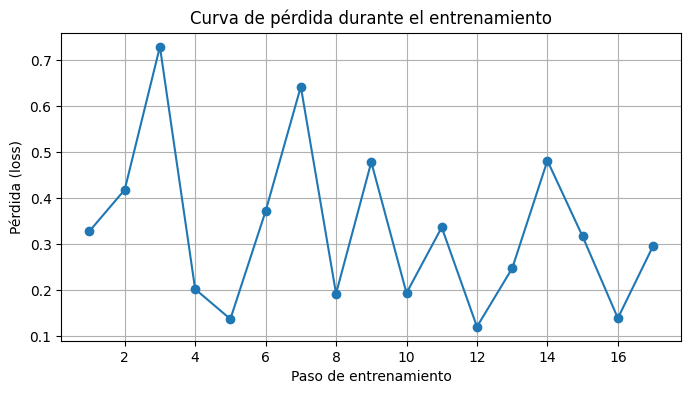

In [12]:
# Curva de error
import pandas as pd
import matplotlib.pyplot as plt

# 📁 Leer el archivo de logs del entrenamiento (creado por Trainer)
log_history = trainer.state.log_history

# 📊 Convertir a DataFrame
df_log = pd.DataFrame(log_history)

# 📉 Filtrar solo los logs que contienen 'loss'
df_loss = df_log[df_log["loss"].notnull()]

# 🖼️ Graficar la pérdida por paso
plt.figure(figsize=(8,4))
plt.plot(df_loss["step"], df_loss["loss"], marker='o')
plt.xlabel("Paso de entrenamiento")
plt.ylabel("Pérdida (loss)")
plt.title("Curva de pérdida durante el entrenamiento")
plt.grid(True)
plt.show()


In [13]:
# Evaluación sobre el conjunto de Test
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import torch

# 🧪 Dataset de evaluación
test_dataset = encoded_ds['test']

# 🧠 Función para predecir con batch
def predict(model, dataset):
    model.eval()
    preds, labels = [], []

    for batch in torch.utils.data.DataLoader(dataset, batch_size=4):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()

        preds.extend(batch_preds)
        labels.extend(batch['label'].numpy())

    return preds, labels

preds, true_labels = predict(model, test_dataset)


In [14]:
# Cálculo de métricas
accuracy = accuracy_score(true_labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, preds, average='binary')

print("🔍 Evaluación del modelo LoRA:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


🔍 Evaluación del modelo LoRA:
Accuracy : 0.7333
Precision: 1.0000
Recall   : 0.1111
F1-score : 0.2000


📋 Classification Report:
              precision    recall  f1-score   support

         ham       0.72      1.00      0.84        21
        spam       1.00      0.11      0.20         9

    accuracy                           0.73        30
   macro avg       0.86      0.56      0.52        30
weighted avg       0.81      0.73      0.65        30



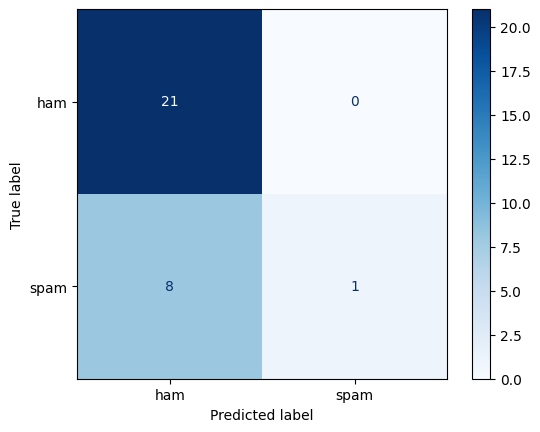

In [15]:
# Detalle y Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("📋 Classification Report:")
print(classification_report(true_labels, preds, target_names=["ham", "spam"]))

cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap='Blues')
plt.show()